# Image Classfication


# Executive Summery
Image classification is a powerful and rapidly advancing field within computer vision, driven by the capabilities of deep learning. The scope of using it to the industry is vast, it can used in Product identification and recommendation systems,Facial recognition for authentication and surveillance etc.
Here we can see its use in fashion industry.

# Table of Contains
# 1.Data Preprocessing
# 2.Visualization
# 3.Model Training
# 4.Conclusion

In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


# image classfication

In [1]:
from zipfile import ZipFile  # to creating, reading, writing, appending, and extracting ZIP files
import os
zip_file_path = "D:\women-fashion.zip" #holds the path to the ZIP file to be extract
extraction_directory ="D:\women-fashion" # defines the directory where the contents of the ZIP file will be extracted

if not os.path.exists(extraction_directory): # checks if the extraction directory already exist
    os.makedirs(extraction_directory) #it's ensures that the extraction directory is available before attempting to extract files into it.

with ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_directory)  # opens  the ZIP file in read mode and stores the contents of the ZIP file into the specified directory

extracted_files = os.listdir(extraction_directory)  # it lists all the files and directories in the specified extraction directory
print(extracted_files[:10])

['women fashion', '__MACOSX']


In [2]:
extraction_directory_updated = os.path.join(extraction_directory,'women fashion') # combining the base extraction directory with sub-directory to creat a new path
extracted_directory_updated = os.listdir(extraction_directory_updated) #  lists all files and directories within the "extraction_directory_updated" path
extracted_directory_updated[:10], len(extracted_directory_updated) # the list of the first ten items

(['anarkali suit with a long, olive green kurta adorned with intricate embroidery around the neckline and cuffs, paired with matching fitted trousers.jpg',
  'Anarkali suit with a modern twist.jpg',
  'Anarkali suit with fitted bodice with a high neckline.jpg',
  'anarkali suit with intricate silver embellishments on the neckline, sleeves.jpg',
  'anarkali suit with lavender in color with intricate white patterns throughout the fabric.jpg',
  'anarkali suit. It consists of a turquoise skirt with detailed golden embroidery, a multicolored blouse with floral patterns, and an orange dupatta with lace borders.jpg',
  'ark green, knee-length dress with short sleeves and a white, patterned neckline.jpg',
  'beige top adorned with black dots and a green skirt.jpg',
  'black and white gingham checkered A-line dress with a flared skirt.jpg',
  'black double-breasted blazer with gold buttons, paired with a mid-length skirt.jpg'],
 96)

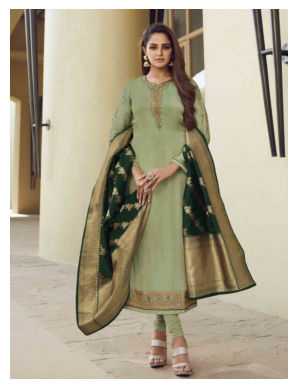

In [3]:
from PIL import Image # "PIL" library used for opening, manipulating, and saving different type of image file formats
import matplotlib.pyplot as plt
def display_image(file_path):   # takes a file path as input and displays the image as output
    image = Image.open(file_path)
    plt.imshow(image)
    plt.axis('off')
    plt.show()
# Combines the updated extraction directory path with the full file path to the first image in the updated extraction directory
first_image_path = os.path.join(extraction_directory_updated,extracted_directory_updated[0])
display_image(first_image_path) # display first image

In [4]:
import glob  # used for matching a specified pattern according to the filename pattern matching
image_directory ="D:\women-fashion\women fashion"

image_paths_list =[file for file in glob.glob(os.path.join(image_directory, '*.*')) if file.endswith(('.jpg','.png','.jpeg','.webp'))]
# finds all files in the specified directory with any file extension and matches file with an extension in the directory
print(image_paths_list) # prints the list of image file paths that match the specified extensions

['D:\\women-fashion\\women fashion\\anarkali suit with a long, olive green kurta adorned with intricate embroidery around the neckline and cuffs, paired with matching fitted trousers.jpg', 'D:\\women-fashion\\women fashion\\Anarkali suit with a modern twist.jpg', 'D:\\women-fashion\\women fashion\\Anarkali suit with fitted bodice with a high neckline.jpg', 'D:\\women-fashion\\women fashion\\anarkali suit with intricate silver embellishments on the neckline, sleeves.jpg', 'D:\\women-fashion\\women fashion\\anarkali suit with lavender in color with intricate white patterns throughout the fabric.jpg', 'D:\\women-fashion\\women fashion\\anarkali suit. It consists of a turquoise skirt with detailed golden embroidery, a multicolored blouse with floral patterns, and an orange dupatta with lace borders.jpg', 'D:\\women-fashion\\women fashion\\ark green, knee-length dress with short sleeves and a white, patterned neckline.jpg', 'D:\\women-fashion\\women fashion\\beige top adorned with black dot

In [13]:
import tensorflow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input 
from tensorflow.keras.models import Model
import numpy as np

base_model = VGG16(weights='imagenet', include_top=False) # loads the VGG16 model pre-trained on the ImageNet dataset abd removes the fully connected layers at the top of the model
model = Model(inputs=base_model.inputs, outputs=base_model.outputs)  # creates a new model that takes the same inputs and outputs as the VGG16 base model

def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224,224)) # loading image and resizes its to 224*224 pixles,required by VGG16 model
    img_array = image.img_to_array(img)  # converts the image to a NumPy array.
    img_array_expanded = np.expand_dims(img_array, axis=0)  # adds an extra dimension to the array to match the input shape
    return preprocess_input(img_array_expanded) # preprocesses the image array according to the requirements of the VGG16 model

def extract_features(model, preprocessed_img):
    features = model.predict(preprocessed_img) # predict the features of the preprocessed image
    flattened_features = features.flatten()   # flattens the 3D feature map output from the model into a 1D array
    normalized_features = flattened_features / np.linalg.norm(flattened_features)  # ensuring all feature vectors have the same scale
    return normalized_features

all_features = []   # list to store the feature vectors for all images 
all_image_names =[]  # list to store the base names of all image

for img_path in image_paths_list:  # loop repeting it sefl till all the images are processed with the folloing steps : 1.resize to 224x224 pixels, 2.convert to a NumPy array, 3. scaling. 4. process the array
    preprocessed_img = preprocess_image(img_path)
    features = extract_features(model, preprocessed_img)
    all_features.append(features)
    all_image_names.append(os.path.basename(img_path))
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [8]:
from scipy.spatial.distance import cosine  # the cosine module is used here to measure the similarity between image feature vectors

def recommend_fashion_cnn(input_image_path, all_features, all_image_names,model, top_n=5):  # path to the input image for which we want to find similar images
    preprocessed_img = preprocess_image(input_image_path) # process the input image
    input_features = extract_features(model, preprocessed_img) # extracts features from the preprocessed input image

    similarities =[1- cosine(input_features, other_features) for other_features in all_features]  # computes the cosine distance between the input image features and each image in the dataset
    similar_indices = np.argsort(similarities)[-top_n:] # sorts the indices of the similarities in ascending order

    similar_indices = [idx for idx in similar_indices if idx != all_image_names.index(input_image_path)]  # ensures the input image itself is not included in the recommendations

    plt.figure(figsize=(15,10))
    plt.subplot(1, top_n + 1, 1) # creates a subplot for the input image
    plt.imshow(Image.open(input_image_path)) # loads and displays the input image
    plt.title("Input Image")
    plt.axis('off') #turns off axis for cleaner view


    for i, idx in enumerate(similar_indices[:top_n], start=1):  #  iterates over the top "n" similar image indices
       image_path = os.path.join('D:\women-fashion', all_image_names[idx])  # constructs the full path for each recommended image
       plt.subplot(1,top_n + 1, i+ 1) # subplot for each recommended image
       plt.imshow(Image.open(image_path)) #  loads and displays each recommended image
       plt.title(f"Recommendation {i}")  # sets the title of each subplot to indicate the recommendation number
       plt.axis("off")

    plt.tight_layout() #  adjusts the subplots to fit into the figure area
    plt.show() 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


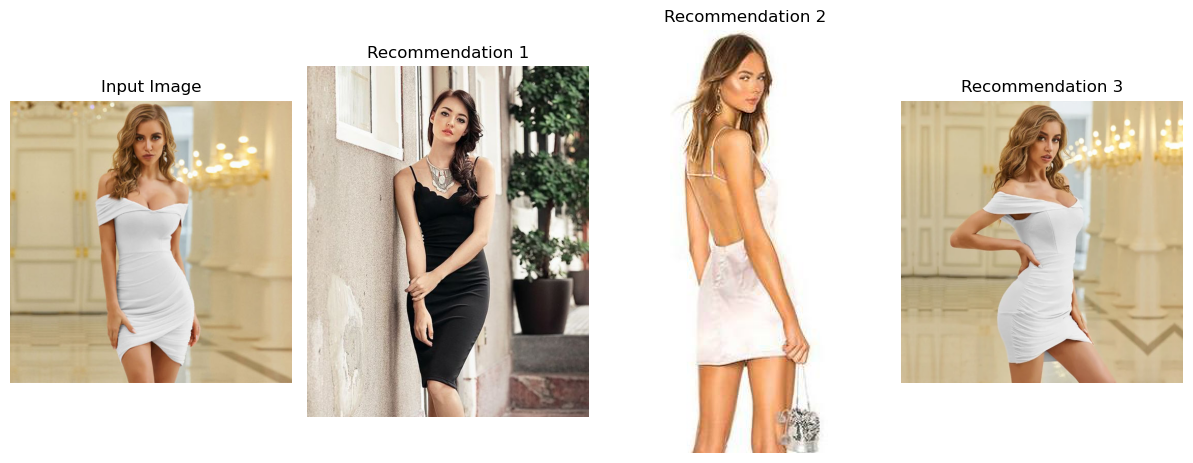

In [9]:
input_image_path ='D:\\women-fashion\\women fashion\\tight-fitting, off-the-shoulder white dress 2.jpg'
# path to the specific image file that we want to use as the input for generating fashion recommendations
recommend_fashion_cnn(input_image_path, all_features, image_paths_list, model, top_n=4)
# recommend similar fashion images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


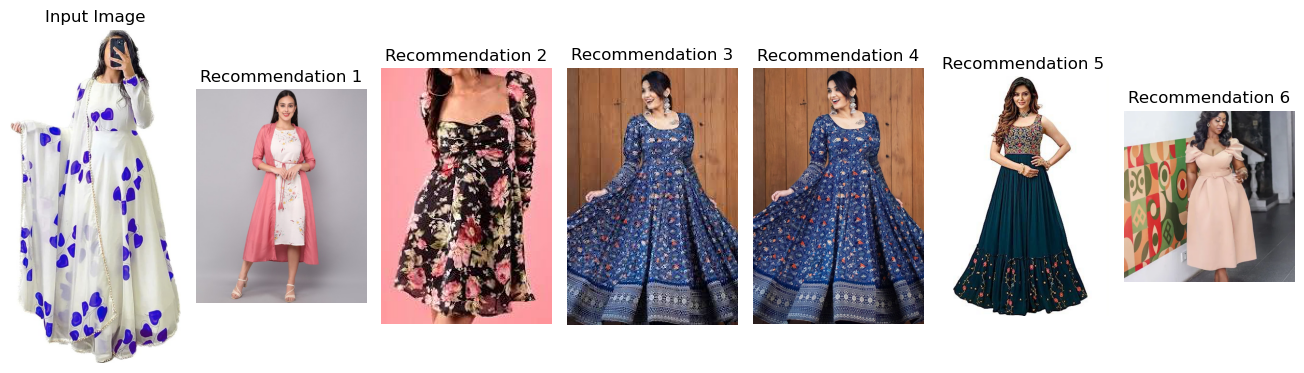

In [10]:
input_image_path ='D:\\women-fashion\\women fashion\\Anarkali suit with a modern twist.jpg'
recommend_fashion_cnn(input_image_path, all_features, image_paths_list, model, top_n=7)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


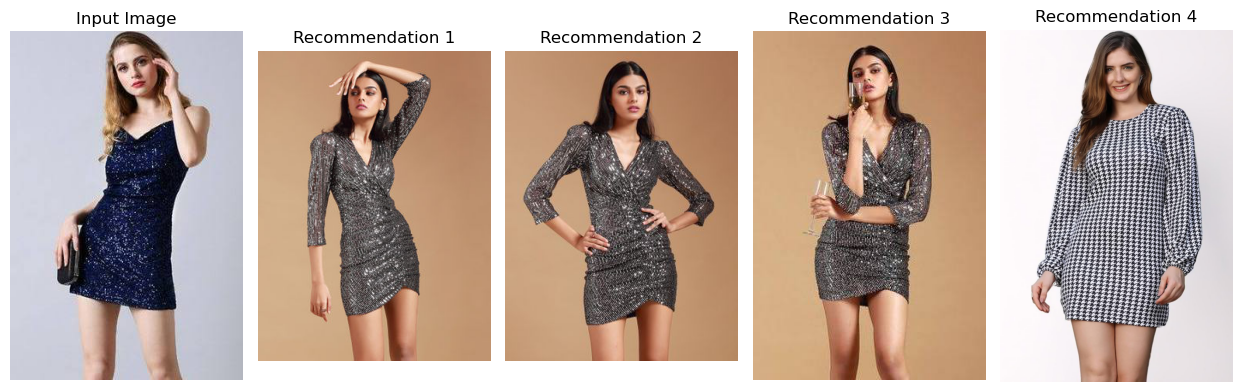

In [11]:
input_image_path ='D:\\women-fashion\\women fashion\\sparkling blue dress.jpeg'
recommend_fashion_cnn(input_image_path, all_features, image_paths_list, model, top_n=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


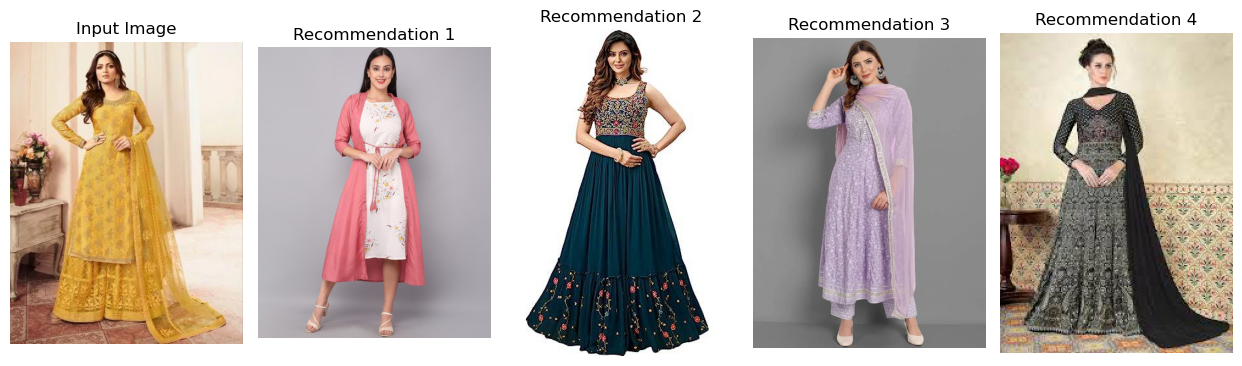

In [12]:
input_image_path ='D:\\women-fashion\\women fashion\\yellow, intricately designed Anarkali suit.jpeg'
recommend_fashion_cnn(input_image_path, all_features, image_paths_list, model, top_n=5)

# Conclusion

The image recommendation system developed in this project effectively demonstrates the application of deep learning for fashion image retrieval. By leveraging a pre-trained convolutional neural network (CNN) model, specifically VGG16, we have successfully created a content-based recommendation engine that suggests visually similar dresses based on an input image

The image recommendation system for fashion items exemplifies how machine learning can be applied to real-world problems to create valuable, this system has the potential to significantly enhance the shopping experience catering to a broader range of applications in the fashion industry.